# Olist E-Commerce Data Cleaning and Analysis

This notebook cleans the Olist datasets, translates Portuguese category labels to English, expands Brazilian state abbreviations to full names, and builds analysis-ready tables with visualizations for a data analyst portfolio.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', palette='Set2')

base_dir = Path.cwd()
if not (base_dir / 'olist_dataset').exists():
    base_dir = Path(r'c:\Users\Veeraditya\Desktop\Olist_Analytics')
data_dir = base_dir / 'olist_dataset'
output_dir = base_dir / 'outputs'
output_dir.mkdir(exist_ok=True)

def load_csv(filename):
    return pd.read_csv(data_dir / filename)

state_full_names = {
    'AC': 'Acre',
    'AL': 'Alagoas',
    'AP': 'Amapa',
    'AM': 'Amazonas',
    'BA': 'Bahia',
    'CE': 'Ceara',
    'DF': 'Federal District',
    'ES': 'Espirito Santo',
    'GO': 'Goias',
    'MA': 'Maranhao',
    'MT': 'Mato Grosso',
    'MS': 'Mato Grosso do Sul',
    'MG': 'Minas Gerais',
    'PA': 'Para',
    'PB': 'Paraiba',
    'PR': 'Parana',
    'PE': 'Pernambuco',
    'PI': 'Piaui',
    'RJ': 'Rio de Janeiro',
    'RN': 'Rio Grande do Norte',
    'RS': 'Rio Grande do Sul',
    'RO': 'Rondonia',
    'RR': 'Roraima',
    'SC': 'Santa Catarina',
    'SP': 'Sao Paulo',
    'SE': 'Sergipe',
    'TO': 'Tocantins'
}

print(f'Working directory: {base_dir}')
print(f'Data directory: {data_dir}')

Working directory: c:\Users\Veeraditya\Desktop\Olist_Analytics
Data directory: c:\Users\Veeraditya\Desktop\Olist_Analytics\olist_dataset


## Load Olist Dataset Files
Read the CSV files from the dataset folder and confirm that each table is available.

In [3]:
customers = load_csv('olist_customers_dataset.csv')
geolocation = load_csv('olist_geolocation_dataset.csv')
orders = load_csv('olist_orders_dataset.csv')
order_items = load_csv('olist_order_items_dataset.csv')
payments = load_csv('olist_order_payments_dataset.csv')
reviews = load_csv('olist_order_reviews_dataset.csv')
products = load_csv('olist_products_dataset.csv')
sellers = load_csv('olist_sellers_dataset.csv')
category_translation = load_csv('product_category_name_translation.csv')

datasets = {
    'customers': customers,
    'geolocation': geolocation,
    'orders': orders,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'category_translation': category_translation,
}

for name, frame in datasets.items():
    print(f'{name}: {frame.shape[0]:,} rows x {frame.shape[1]} columns')
    display(frame.head(2))

customers: 99,441 rows x 5 columns


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP


geolocation: 1,000,163 rows x 5 columns


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP


orders: 99,441 rows x 8 columns


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0


sellers: 3,095 rows x 4 columns


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP


category_translation: 71 rows x 2 columns


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories


## Inspect Tables and Data Types
Check column names, data types, missing values, duplicates, and sample distributions before cleaning.

In [ ]:
def inspect_frame(name, frame):
    print(f'\n{name.upper()}')
    print('-' * 80)
    print(frame.head(3))
    print('\nDtypes:')
    print(frame.dtypes)
    print('\nMissing values:')
    print(frame.isna().sum().sort_values(ascending=False).head(10))
    print(f'\nDuplicate rows: {frame.duplicated().sum():,}')

for name, frame in datasets.items():
    inspect_frame(name, frame)

## Clean Missing Values, Duplicates, and Invalid Entries
Standardize types, remove duplicate rows, and fix known column issues before merging the tables.

In [4]:
def standardize_strings(frame):
    object_columns = frame.select_dtypes(include=['object', 'string']).columns
    for column in object_columns:
        frame[column] = frame[column].astype('string').str.strip()
    return frame

for name in datasets:
    datasets[name] = standardize_strings(datasets[name].copy())

orders = datasets['orders']
order_items = datasets['order_items']
payments = datasets['payments']
reviews = datasets['reviews']
products = datasets['products']
customers = datasets['customers']
geolocation = datasets['geolocation']
sellers = datasets['sellers']
category_translation = datasets['category_translation']

for frame in [customers, geolocation, orders, order_items, payments, reviews, products, sellers, category_translation]:
    frame.drop_duplicates(inplace=True)

for column in [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]:
    orders[column] = pd.to_datetime(orders[column], errors='coerce')

order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], errors='coerce')
for column in ['review_creation_date', 'review_answer_timestamp']:
    reviews[column] = pd.to_datetime(reviews[column], errors='coerce')

for column in ['payment_sequential', 'payment_installments', 'payment_value']:
    payments[column] = pd.to_numeric(payments[column], errors='coerce')

product_numeric_columns = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
]

for column in product_numeric_columns:
    if column in products.columns:
        products[column] = pd.to_numeric(products[column], errors='coerce')

rename_map = {
    'product_name_lenght': 'product_name_length',
    'product_description_lenght': 'product_description_length',
}
existing_renames = {source: target for source, target in rename_map.items() if source in products.columns}
if existing_renames:
    products.rename(columns=existing_renames, inplace=True)

customers.dropna(subset=['customer_id'], inplace=True)
orders.dropna(subset=['order_id', 'customer_id'], inplace=True)
order_items.dropna(subset=['order_id', 'product_id', 'seller_id'], inplace=True)
payments.dropna(subset=['order_id'], inplace=True)
reviews.dropna(subset=['order_id'], inplace=True)
products.dropna(subset=['product_id'], inplace=True)
sellers.dropna(subset=['seller_id'], inplace=True)
category_translation.dropna(subset=['product_category_name'], inplace=True)

print('Duplicates after cleaning:')
for name, frame in [('customers', customers), ('geolocation', geolocation), ('orders', orders), ('order_items', order_items), ('payments', payments), ('reviews', reviews), ('products', products), ('sellers', sellers), ('category_translation', category_translation)]:
    print(f'{name}: {frame.duplicated().sum():,}')

Duplicates after cleaning:
customers: 0
geolocation: 0
orders: 0
order_items: 0
payments: 0
reviews: 0
products: 0
sellers: 0
category_translation: 0


## Translate Portuguese Fields to English
Use the provided category translation table and rename columns to business-friendly English labels.

In [5]:
products = products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

products['product_category_name_english'] = products['product_category_name_english'].fillna(products['product_category_name'])

category_translation_map = dict(
    zip(category_translation['product_category_name'], category_translation['product_category_name_english'])
)

rename_map = {
    'customer_zip_code_prefix': 'customer_zip_code_prefix',
    'customer_city': 'customer_city',
    'customer_state': 'customer_state',
    'geolocation_zip_code_prefix': 'geolocation_zip_code_prefix',
    'geolocation_city': 'geolocation_city',
    'geolocation_state': 'geolocation_state',
    'seller_zip_code_prefix': 'seller_zip_code_prefix',
    'seller_city': 'seller_city',
    'seller_state': 'seller_state',
}

print('Categories without translation:')
missing_translation = products.loc[products['product_category_name_english'].isna(), 'product_category_name'].dropna().unique()
print(missing_translation)

products[['product_category_name', 'product_category_name_english']].head(10)

Categories without translation:
<StringArray>
[]
Length: 0, dtype: string


,product_category_name,product_category_name_english
0,perfumaria,perfumery
1,artes,art
2,esporte_lazer,sports_leisure
3,bebes,baby
4,utilidades_domesticas,housewares
5,instrumentos_musicais,musical_instruments
6,cool_stuff,cool_stuff
7,moveis_decoracao,furniture_decor
8,eletrodomesticos,home_appliances
9,brinquedos,toys


## Expand Brazilian State Abbreviations to Full State Names
Convert state abbreviations in customer, seller, and geolocation data into readable full names.

In [6]:
def expand_state_column(frame, column):
    full_column = f'{column}_full_name'
    frame[full_column] = frame[column].map(state_full_names).fillna(frame[column])
    return frame

customers = expand_state_column(customers, 'customer_state')
sellers = expand_state_column(sellers, 'seller_state')
geolocation = expand_state_column(geolocation, 'geolocation_state')

for frame_name, frame, column in [
    ('customers', customers, 'customer_state_full_name'),
    ('sellers', sellers, 'seller_state_full_name'),
    ('geolocation', geolocation, 'geolocation_state_full_name'),
]:
    print(frame_name)
    print(frame[[column]].drop_duplicates().head())

customers
   customer_state_full_name
0                 Sao Paulo
5            Santa Catarina
7              Minas Gerais
8                    Parana
11           Rio de Janeiro
sellers
   seller_state_full_name
0               Sao Paulo
2          Rio de Janeiro
6              Pernambuco
9                  Parana
10                  Goias
geolocation
       geolocation_state_full_name
0                        Sao Paulo
22261          Rio Grande do Norte
72852                         Acre
404270              Rio de Janeiro
525441              Espirito Santo


## Merge Tables for Analysis
Join the cleaned tables with the correct keys and keep the result analysis-ready without duplicating order-level values.

In [7]:
payments_summary = (
    payments.groupby('order_id', as_index=False)
    .agg(
        total_payment_value=('payment_value', 'sum'),
        payment_installments=('payment_installments', 'max'),
        payment_type=('payment_type', lambda series: series.mode().iat[0] if not series.mode().empty else series.iloc[0]),
    )
)

reviews_summary = (
    reviews.groupby('order_id', as_index=False)
    .agg(
        review_score=('review_score', 'mean'),
        review_comment_title=('review_comment_title', 'first'),
        review_comment_message=('review_comment_message', 'first'),
        review_creation_date=('review_creation_date', 'first'),
        review_answer_timestamp=('review_answer_timestamp', 'first'),
    )
)

analysis_df = (
    order_items
    .merge(orders, on='order_id', how='left', validate='many_to_one')
    .merge(customers, on='customer_id', how='left', validate='many_to_one')
    .merge(products[['product_id', 'product_category_name', 'product_category_name_english', 'product_name_length', 'product_description_length', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']], on='product_id', how='left', validate='many_to_one')
    .merge(sellers[['seller_id', 'seller_city', 'seller_state', 'seller_state_full_name']], on='seller_id', how='left', validate='many_to_one')
    .merge(payments_summary, on='order_id', how='left', validate='many_to_one')
    .merge(reviews_summary, on='order_id', how='left', validate='many_to_one')
)

print(analysis_df.shape)
analysis_df.head()

(112650, 39)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_state_full_name,product_category_name,product_category_name_english,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_city,seller_state,seller_state_full_name,total_payment_value,payment_installments,payment_type,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,Rio de Janeiro,cool_stuff,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,volta redonda,SP,Sao Paulo,72.19,2.0,credit_card,5.0,<NA>,"Perfeito, produto entregue antes do combinado.",2017-09-21,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,Sao Paulo,pet_shop,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,sao paulo,SP,Sao Paulo,259.83,3.0,credit_card,4.0,<NA>,<NA>,2017-05-13,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,Minas Gerais,moveis_decoracao,furniture_decor,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,borda da mata,MG,Minas Gerais,216.87,5.0,credit_card,5.0,<NA>,Chegou antes do prazo previsto e o produto sur...,2018-01-23,2018-01-23 16:06:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,Sao Paulo,perfumaria,perfumery,42.0,480.0,1.0,200.0,16.0,10.0,15.0,franca,SP,Sao Paulo,25.78,2.0,credit_card,4.0,<NA>,<NA>,2018-08-15,2018-08-15 16:39:01
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,Sao Paulo,ferramentas_jardim,garden_tools,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,loanda,PR,Parana,218.04,3.0,credit_card,5.0,<NA>,Gostei pois veio no prazo determinado .,2017-03-02,2017-03-03 10:54:59


## Create Summary Metrics and Feature Columns
Engineer delivery, order, revenue, and review features that support business analysis.

In [8]:
analysis_df['delivery_time_days'] = (analysis_df['order_delivered_customer_date'] - analysis_df['order_purchase_timestamp']).dt.days
analysis_df['approval_time_hours'] = (analysis_df['order_approved_at'] - analysis_df['order_purchase_timestamp']).dt.total_seconds() / 3600
analysis_df['delivery_delay_days'] = (analysis_df['order_delivered_customer_date'] - analysis_df['order_estimated_delivery_date']).dt.days
analysis_df['shipping_time_days'] = (analysis_df['order_delivered_customer_date'] - analysis_df['order_delivered_carrier_date']).dt.days
analysis_df['order_month'] = analysis_df['order_purchase_timestamp'].dt.strftime('%B %Y')
analysis_df['order_weekday'] = analysis_df['order_purchase_timestamp'].dt.day_name()
analysis_df['is_delayed'] = analysis_df['delivery_delay_days'] > 0
analysis_df['order_value_per_item'] = analysis_df['price'] + analysis_df['freight_value']
analysis_df['review_category'] = pd.cut(
    analysis_df['review_score'],
    bins=[0, 2, 4, 5],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True,
)

summary_metrics = (
    analysis_df.groupby('product_category_name_english', as_index=False)
    .agg(
        total_revenue=('total_payment_value', 'sum'),
        order_count=('order_id', 'nunique'),
        avg_review_score=('review_score', 'mean'),
        avg_delivery_time=('delivery_time_days', 'mean'),
    )
    .sort_values('total_revenue', ascending=False)
)

summary_metrics.head(10)

,product_category_name_english,total_revenue,order_count,avg_review_score,avg_delivery_time
7,bed_bath_table,1712553.67,9417,3.898334,12.336803
43,health_beauty,1657373.12,8836,4.141827,11.516954
15,computers_accessories,1585330.45,6689,3.932601,12.779799
39,furniture_decor,1430176.39,6449,3.907333,12.404044
72,watches_gifts,1429216.68,5624,4.018855,12.191736
67,sports_leisure,1392127.56,7720,4.107039,11.692563
49,housewares,1094758.13,5884,4.054785,10.456512
5,auto,852294.33,3897,4.064885,11.766369
42,garden_tools,838280.75,3518,4.045539,13.231959
20,cool_stuff,779698.00,3632,4.146598,11.898601


## Visualize Trends with Seaborn and Matplotlib
Build a compact set of plots that highlights sales, customer geography, delivery performance, and review behavior.

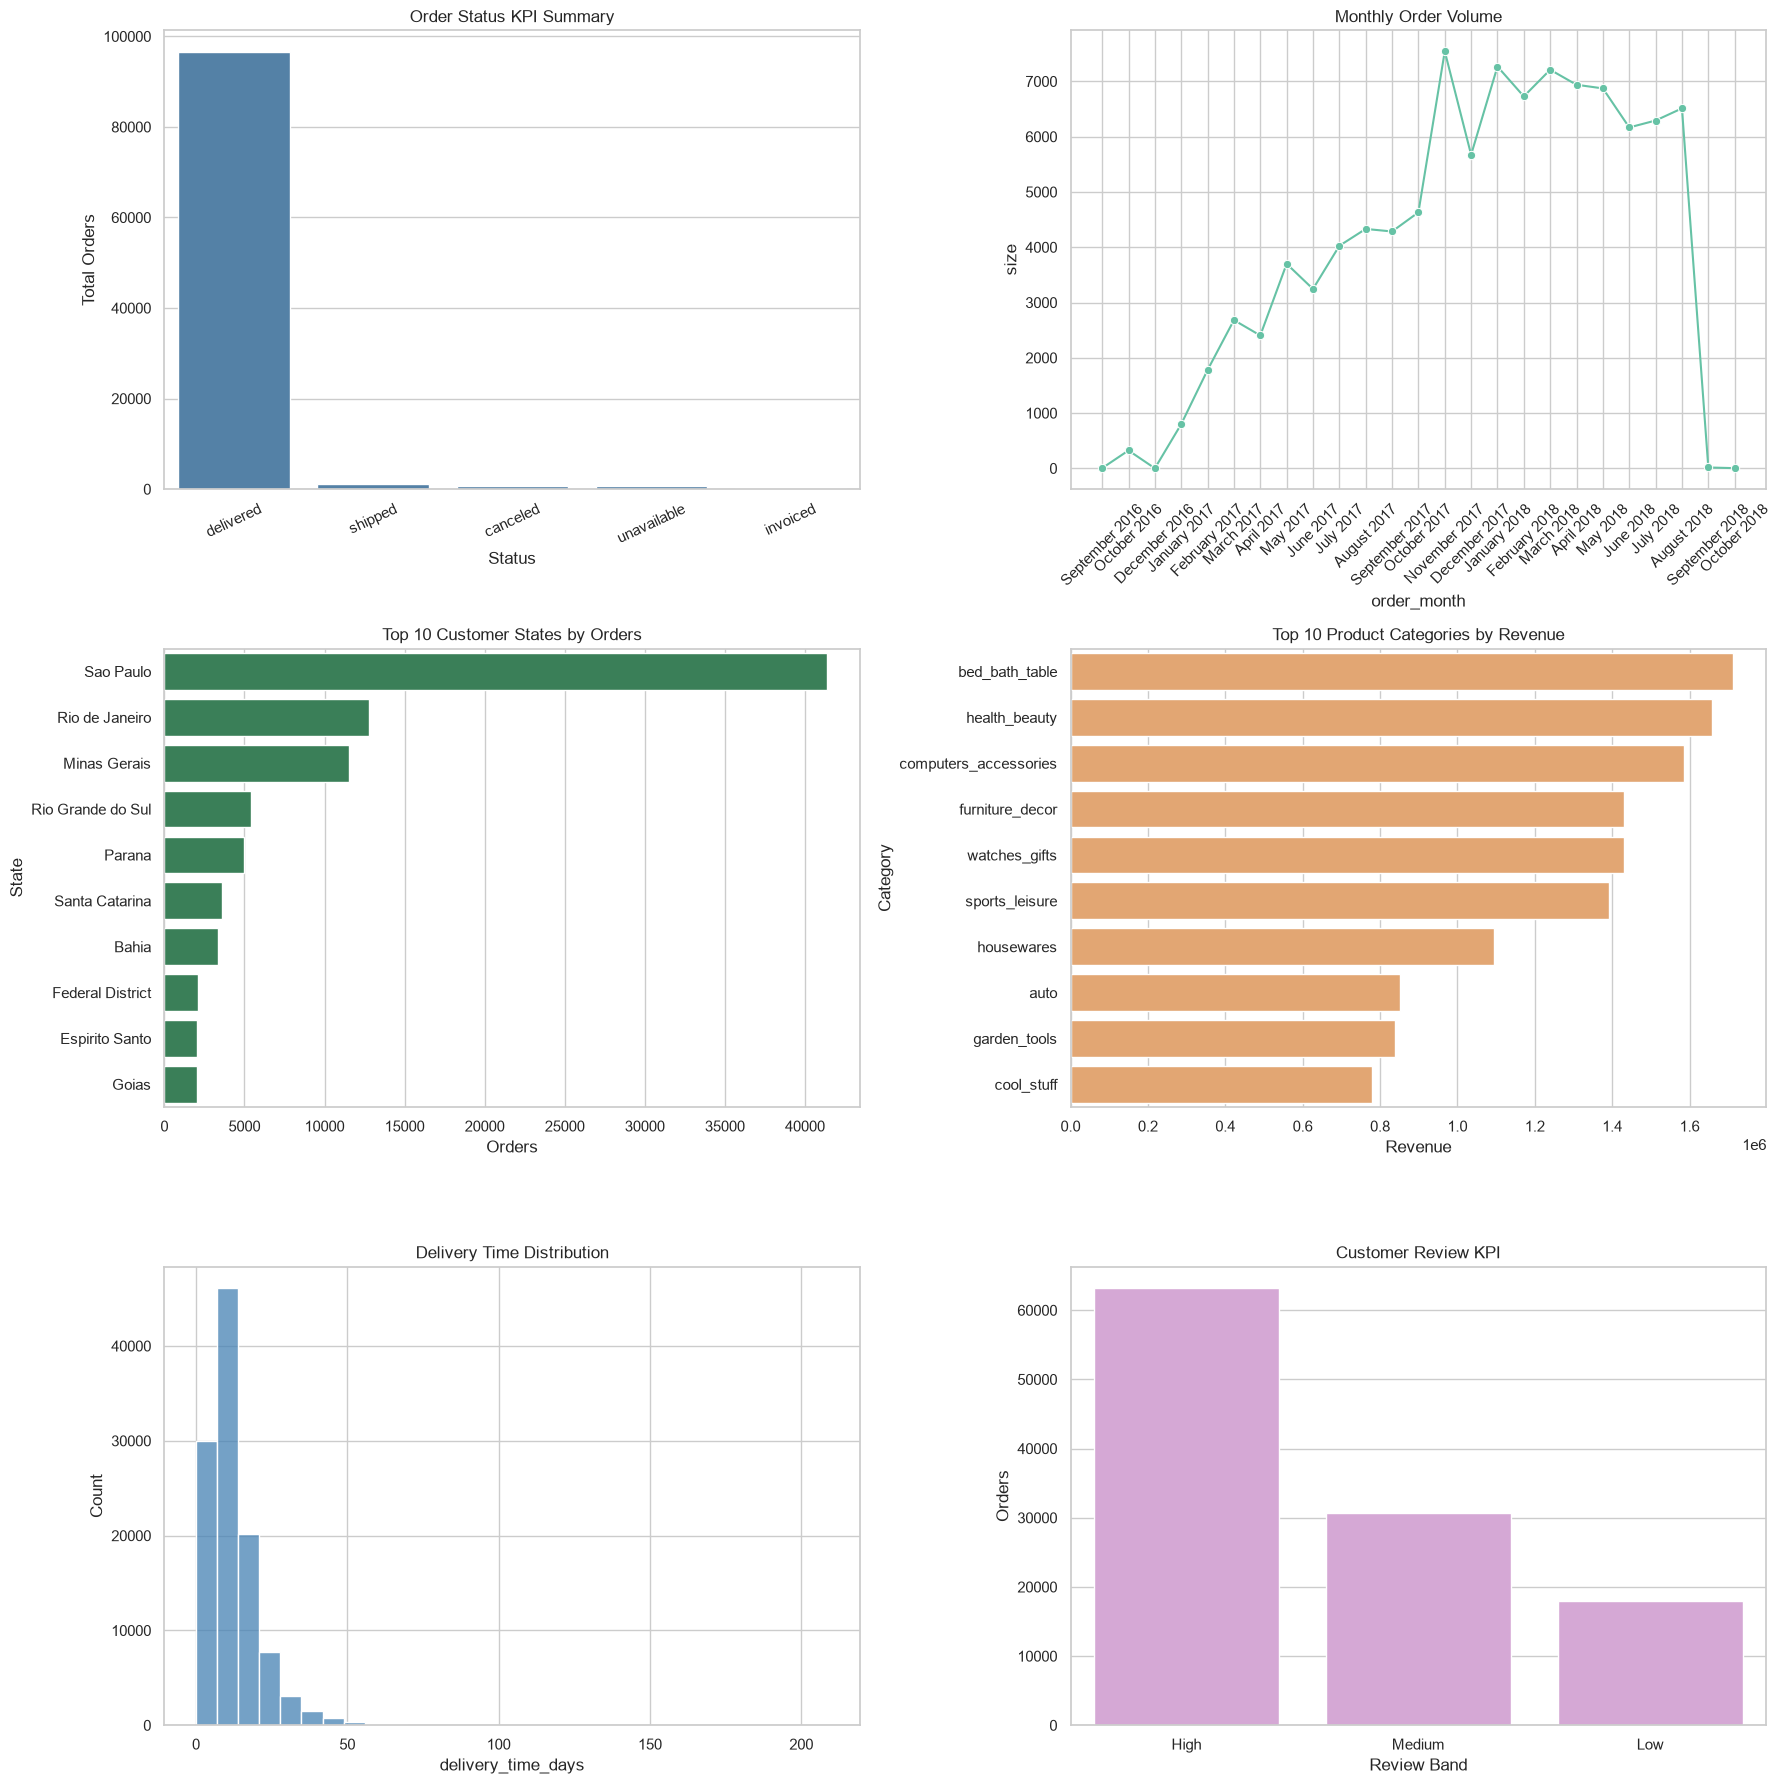

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

kpi_status_order = ['delivered', 'shipped', 'canceled', 'unavailable', 'invoiced']
order_status_counts = (
    orders['order_status']
    .value_counts()
    .reindex(kpi_status_order)
    .fillna(0)
    .reset_index()
)
order_status_counts.columns = ['order_status', 'count']
sns.barplot(data=order_status_counts, x='order_status', y='count', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Order Status KPI Summary')
axes[0, 0].set_xlabel('Status')
axes[0, 0].set_ylabel('Total Orders')
axes[0, 0].tick_params(axis='x', rotation=25)

monthly_orders = orders.assign(order_month=orders['order_purchase_timestamp'].dt.strftime('%B %Y'))
monthly_orders = monthly_orders.groupby('order_month', as_index=False).size()
monthly_orders['month_sort'] = pd.to_datetime(monthly_orders['order_month'], format='%B %Y')
monthly_orders = monthly_orders.sort_values('month_sort')
sns.lineplot(data=monthly_orders, x='order_month', y='size', marker='o', ax=axes[0, 1])
axes[0, 1].set_title('Monthly Order Volume')
axes[0, 1].tick_params(axis='x', rotation=45)

state_orders = analysis_df.groupby('customer_state_full_name', as_index=False)['order_id'].nunique().sort_values('order_id', ascending=False).head(10)
sns.barplot(data=state_orders, x='order_id', y='customer_state_full_name', ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Top 10 Customer States by Orders')
axes[1, 0].set_xlabel('Orders')
axes[1, 0].set_ylabel('State')

category_orders = summary_metrics.head(10)
sns.barplot(data=category_orders, x='total_revenue', y='product_category_name_english', ax=axes[1, 1], color='sandybrown')
axes[1, 1].set_title('Top 10 Product Categories by Revenue')
axes[1, 1].set_xlabel('Revenue')
axes[1, 1].set_ylabel('Category')

sns.histplot(data=analysis_df, x='delivery_time_days', bins=30, ax=axes[2, 0], color='steelblue')
axes[2, 0].set_title('Delivery Time Distribution')

review_kpi = analysis_df['review_category'].value_counts().reindex(['High', 'Medium', 'Low']).fillna(0).reset_index()
review_kpi.columns = ['review_category', 'count']
sns.barplot(data=review_kpi, x='review_category', y='count', ax=axes[2, 1], color='plum')
axes[2, 1].set_title('Customer Review KPI')
axes[2, 1].set_xlabel('Review Band')
axes[2, 1].set_ylabel('Orders')

plt.tight_layout()

## Export the Cleaned Dataset
Save the cleaned and translated analysis table to a reusable file for reporting or dashboard work.

In [10]:
cleaned_output_path = output_dir / 'olist_cleaned_analysis_ready.csv'
analysis_df.to_csv(cleaned_output_path, index=False)

geolocation_output_path = output_dir / 'olist_geolocation_cleaned.csv'
geolocation[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state', 'geolocation_state_full_name']].drop_duplicates().to_csv(geolocation_output_path, index=False)

print(f'Saved cleaned dataset to: {cleaned_output_path}')
print(f'Saved geolocation dataset to: {geolocation_output_path}')
print(f'Final analysis table shape: {analysis_df.shape}')
analysis_df.head()

Saved cleaned dataset to: c:\Users\Veeraditya\Desktop\Olist_Analytics\outputs\olist_cleaned_analysis_ready.csv
Saved geolocation dataset to: c:\Users\Veeraditya\Desktop\Olist_Analytics\outputs\olist_geolocation_cleaned.csv
Final analysis table shape: (112650, 48)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_state_full_name,product_category_name,product_category_name_english,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_city,seller_state,seller_state_full_name,total_payment_value,payment_installments,payment_type,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_time_days,approval_time_hours,delivery_delay_days,shipping_time_days,order_month,order_weekday,is_delayed,order_value_per_item,review_category
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,Rio de Janeiro,cool_stuff,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,volta redonda,SP,Sao Paulo,72.19,2.0,credit_card,5.0,<NA>,"Perfeito, produto entregue antes do combinado.",2017-09-21,2017-09-22 10:57:03,7.0,0.775833,-9.0,1.0,September 2017,Wednesday,False,72.19,High
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,Sao Paulo,pet_shop,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,sao paulo,SP,Sao Paulo,259.83,3.0,credit_card,4.0,<NA>,<NA>,2017-05-13,2017-05-15 11:34:13,16.0,0.201944,-3.0,8.0,April 2017,Wednesday,False,259.83,Medium
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,Minas Gerais,moveis_decoracao,furniture_decor,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,borda da mata,MG,Minas Gerais,216.87,5.0,credit_card,5.0,<NA>,Chegou antes do prazo previsto e o produto sur...,2018-01-23,2018-01-23 16:06:31,7.0,0.249722,-14.0,6.0,January 2018,Sunday,False,216.87,High
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,Sao Paulo,perfumaria,perfumery,42.0,480.0,1.0,200.0,16.0,10.0,15.0,franca,SP,Sao Paulo,25.78,2.0,credit_card,4.0,<NA>,<NA>,2018-08-15,2018-08-15 16:39:01,6.0,0.161944,-6.0,4.0,August 2018,Wednesday,False,25.78,Medium
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,Sao Paulo,ferramentas_jardim,garden_tools,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,loanda,PR,Parana,218.04,3.0,credit_card,5.0,<NA>,Gostei pois veio no prazo determinado .,2017-03-02,2017-03-03 10:54:59,25.0,0.206111,-16.0,13.0,February 2017,Saturday,False,218.04,High
